In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing


In [2]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print("Dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

display(X.head())

Dataset loaded successfully!
Features shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully!")
display(X_scaled_df.head())

Features scaled successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Simple Linear Regression MSE: 0.7091
Simple Linear Regression RMSE: 0.8421
Simple Linear Regression R2 Score: 0.4589


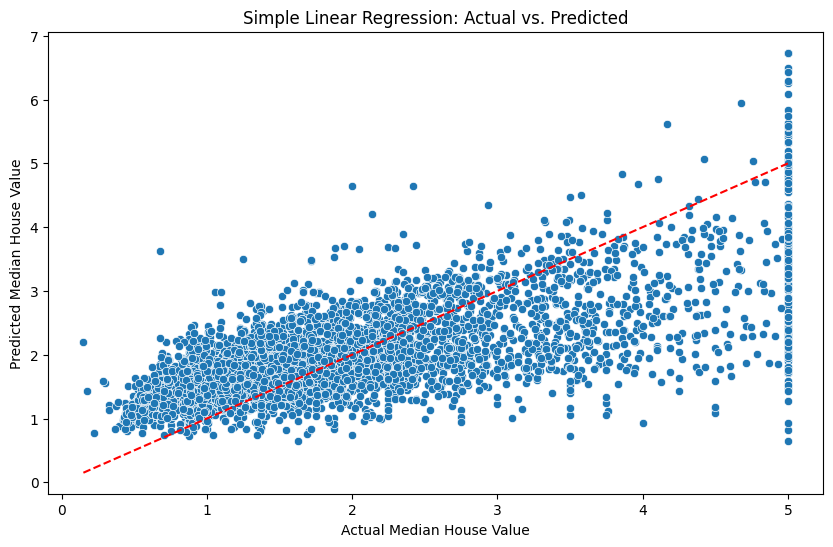

In [9]:
# For simple linear regression, let's use 'MedInc' (Median Income) as the single feature
X_simple = X_scaled[:, 0].reshape(-1, 1) # Reshape for single feature
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_lr_model = LinearRegression()
simple_lr_model.fit(X_train_simple, y_train_simple)
y_pred_simple = simple_lr_model.predict(X_test_simple)

mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print(f"Simple Linear Regression MSE: {mse_simple:.4f}")
print(f"Simple Linear Regression RMSE: {rmse_simple:.4f}")
print(f"Simple Linear Regression R2 Score: {r2_simple:.4f}")

# Plotting predictions vs actual for simple LR
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_simple, y=y_pred_simple)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Simple Linear Regression: Actual vs. Predicted')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

Multiple Linear Regression MSE: 0.5559
Multiple Linear Regression RMSE: 0.7456
Multiple Linear Regression R2 Score: 0.5758


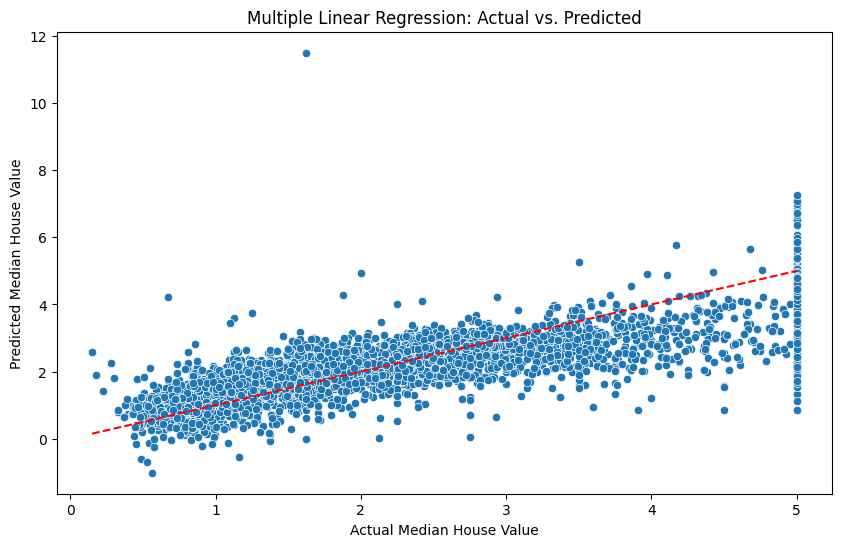

In [10]:
multiple_lr_model = LinearRegression()
multiple_lr_model.fit(X_train, y_train)
y_pred_multiple = multiple_lr_model.predict(X_test)

mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f"Multiple Linear Regression MSE: {mse_multiple:.4f}")
print(f"Multiple Linear Regression RMSE: {rmse_multiple:.4f}")
print(f"Multiple Linear Regression R2 Score: {r2_multiple:.4f}")

# Plotting predictions vs actual for multiple LR
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_multiple)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Multiple Linear Regression: Actual vs. Predicted')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()